In [ ]:
import pandas as pd
from scipy import stats
import numpy as np
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
from scipy.stats import t
import seaborn as sns

pd.options.mode.chained_assignment = None

In [ ]:
df = pd.read_excel('/content/S2_data_raw.xlsx')
columns = df.iloc[0, :].to_list()

In [ ]:
# проверки на внимательность
df = df[(df['Q6d'] == 2) & (df['Q31a'] == 3) & (df['Q53a'] == 5)]

# удаляем отрицательные значения
df = df[~(df < 0).any(axis=1)]

# норм названия колонок
df.columns = columns

# все в числовой тип
df = df.apply(pd.to_numeric, errors="coerce")

In [ ]:
df

,inform_agree,check0,pervy_canal,rossiya1,rossiya24,country_right_way,benefit of people,power is right,check1,sovfed,...,imp_childlessness_tax,topic_sec_foreign_lang,imp_sec_foreign_lang,topic_euthan,imp_euthan,gender,age,educ,money,city
1,1,5,1,1,1,1,1,1,2,1,...,1,1,1,1,1,2,1,4,4,2
2,1,5,4,3,2,4,4,4,2,4,...,5,3,3,5,4,2,2,3,3,3
5,1,5,1,1,1,4,4,4,2,4,...,1,1,1,3,4,2,1,5,2,3
7,1,5,4,2,2,3,3,4,2,5,...,2,5,4,3,4,1,6,3,3,3
10,1,5,2,1,1,4,4,4,2,6,...,4,4,4,4,4,2,2,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,1,5,3,3,3,4,4,4,2,4,...,4,4,4,4,4,1,3,5,3,2
403,1,5,5,5,4,7,5,4,2,5,...,5,5,5,3,5,1,3,3,3,5
404,1,5,5,5,4,7,7,4,2,7,...,4,4,4,4,4,1,3,4,2,4
405,1,5,4,3,2,3,3,4,2,4,...,6,6,6,6,6,2,2,3,4,3


# I. **проведем анализ без учета не уверенных в своей групповой принадлежности респондентов**

In [ ]:
# удаляем не уверенных в поддержке руководства
df = df[df['support'] != 3]

In [ ]:
#0,1,2 - критики власти, 4,5,6 - сторонники
df["support_bin"] = np.where(df["support"].isin([0, 1, 2]), 0, 1)
df["support_bin"].value_counts()

,count
support_bin,
1,159
0,101


In [ ]:
a = df[df['support_bin'] == 0]['critic_identity'].value_counts().sort_index()
print(f'Процент  тех, кто не поддерживает власть и относит себя к критикам: {a.loc[[5, 6, 7]].sum() / a.sum() * 100:.2f}')


b = df[df['support_bin'] == 1]['supporter_identity'].value_counts().sort_index()
print(f'Процент тех, кто поддерживает власть и относит себя к сторонникам: {b.loc[[5, 6, 7]].sum() / b.sum() * 100:.2f}')

Процент  тех, кто не поддерживает власть и относит себя к критикам: 57.43
Процент тех, кто поддерживает власть и относит себя к сторонникам: 69.81


In [ ]:
cols_alpha1 = ["country_right_way", "benefit of people", "power is right"]
cols_alpha2 = ["pervy_canal", "rossiya1", "rossiya24"]
cols_alpha3 = ['sovfed', 'gosduma', 'verh_sud', 'pravitelstvo', 'president', 'fsb']

def cronbach_alpha(data):
    data = data.apply(pd.to_numeric, errors="coerce")
    data = data.dropna()

    k = data.shape[1]

    item_variances = data.var(axis=0, ddof=1)
    total_score = data.sum(axis=1)
    total_variance = total_score.var(ddof=1)

    alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)

    return alpha

print(f'Альфа кронбаха для утверждений: {cronbach_alpha(df[cols_alpha1]):.2f}')
print(f'Альфа кронбаха для просмотра федеральных сми: {cronbach_alpha(df[cols_alpha2]):.2f}')
print(f'Альфа кронбаха для доверия органам власти: {cronbach_alpha(df[cols_alpha3]):.2f}')

Альфа кронбаха для утверждений: 0.96
Альфа кронбаха для просмотра федеральных сми: 0.92
Альфа кронбаха для доверия органам власти: 0.97


In [ ]:
# проверим разделяют ли эти вопросы сторонников и критиков власти

# утверждения
df['statements'] = df[["country_right_way",  "benefit of people",  "power is right"]].mean(axis = 1)
if ttest_ind(df[df['support_bin'] == 0]['statements'], df[df['support_bin'] == 1]['statements'])[1] < 0.05:
  print('утверждения разделяют')

# сми
df['smi'] = df[["pervy_canal", "rossiya1", "rossiya24"]].mean(axis = 1)
if ttest_ind(df[df['support_bin'] == 0]['smi'], df[df['support_bin'] == 1]['smi'])[1] < 0.05:
  print('просмотр сми разделяет')

# доверие
df['trust'] = df[['sovfed', 'gosduma', 'verh_sud', 'pravitelstvo', 'president', 'fsb']].mean(axis = 1)
if ttest_ind(df[df['support_bin'] == 0]['trust'], df[df['support_bin'] == 1]['trust'])[1] < 0.05:
  print('доверие разделяет')

утверждения разделяют
просмотр сми разделяет
доверие разделяет


# Анализ тем

In [ ]:
topic_cols = [col for col in df.columns if col.startswith("topic_")]
imp_cols = [col for col in df.columns if col.startswith("imp_")]

In [ ]:
corr_matrix = df[topic_cols].corr()
def highlight_corr(val):
    if val > 0.5:
        return 'background-color: red'
    elif val < -0.5:
        return 'background-color: lightblue'
    return ''

corr_matrix = df[topic_cols].corr()
corr_matrix.style.applymap(highlight_corr)

/tmp/ipykernel_47846/3315058578.py:10: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  corr_matrix.style.applymap(highlight_corr)


,topic_vpn,topic_wesp_coop,topic_postgrad_work,topic_patr_class,topic_bord_screen,topic_army,topic_allies_help,topic_immigr,topic_citiz_depriv,topic_progr_tax,topic_west_sanct,topic_death_pen,topic_circus_animal,topic_milit_indust,topic_fest,topic_messenger,topic_milit_force,topic_abort,topic_nationalization,topic_prohib_adopt,topic_relig_educ,topic_childlessness_tax,topic_sec_foreign_lang,topic_euthan
topic_vpn,1.000000,-0.154543,0.370293,0.510640,0.509330,0.450723,0.439589,0.151636,0.440728,0.141905,-0.201599,0.276362,-0.173264,0.465929,0.030603,0.575070,0.411218,0.312872,0.354917,0.371863,0.437922,0.494058,-0.018662,-0.313558
topic_wesp_coop,-0.154543,1.000000,-0.170873,-0.379487,-0.271294,-0.357724,-0.212770,-0.067764,-0.371875,-0.054669,0.544852,-0.244979,0.142932,-0.259820,0.102145,-0.256167,-0.346184,-0.293062,-0.229111,-0.341833,-0.291922,-0.164449,0.174564,0.122204
topic_postgrad_work,0.370293,-0.170873,1.000000,0.563004,0.466076,0.549320,0.442240,0.320922,0.554915,0.258381,-0.165857,0.463627,-0.154049,0.365521,0.111187,0.562027,0.542410,0.408885,0.472849,0.446357,0.374246,0.408323,0.121115,-0.062464
topic_patr_class,0.510640,-0.379487,0.563004,1.000000,0.631887,0.741611,0.604372,0.330233,0.672635,0.250697,-0.248751,0.509027,-0.155557,0.470740,0.171275,0.661446,0.684560,0.497985,0.545324,0.490715,0.539904,0.388810,0.047865,-0.112367
topic_bord_screen,0.509330,-0.271294,0.466076,0.631887,1.000000,0.570847,0.494321,0.376665,0.568044,0.237724,-0.291038,0.438822,-0.128656,0.431158,0.085714,0.566599,0.592522,0.384438,0.425244,0.512583,0.323775,0.306797,0.050022,-0.104045
topic_army,0.450723,-0.357724,0.549320,0.741611,0.570847,1.000000,0.533198,0.354921,0.606799,0.221131,-0.243506,0.476477,-0.175078,0.389706,0.133377,0.582586,0.640795,0.454252,0.526016,0.519475,0.463767,0.287762,0.039925,-0.160397
topic_allies_help,0.439589,-0.212770,0.442240,0.604372,0.494321,0.533198,1.000000,0.277306,0.580552,0.216115,-0.210111,0.306274,-0.096781,0.489969,0.279154,0.549084,0.557165,0.391505,0.575741,0.456482,0.368468,0.270201,0.042169,-0.148805
topic_immigr,0.151636,-0.067764,0.320922,0.330233,0.376665,0.354921,0.277306,1.000000,0.446290,0.409494,-0.068092,0.406872,0.009129,0.076485,0.102433,0.192906,0.398171,0.105911,0.321520,0.347097,0.006305,0.039867,-0.042540,0.133709
topic_citiz_depriv,0.440728,-0.371875,0.554915,0.672635,0.568044,0.606799,0.580552,0.446290,1.000000,0.298891,-0.296861,0.502338,-0.140012,0.448345,0.082216,0.584015,0.685088,0.437164,0.518824,0.522518,0.404453,0.343114,0.052470,-0.028217
topic_progr_tax,0.141905,-0.054669,0.258381,0.250697,0.237724,0.221131,0.216115,0.409494,0.298891,1.000000,0.087848,0.322926,-0.033250,0.015094,-0.003854,0.183822,0.235739,0.162102,0.295410,0.244840,0.051027,0.076288,0.097984,0.005438


# Важность тем

In [ ]:
print('Среднее важности по темам')
df[imp_cols].mean().sort_values(ascending = False)

Среднее важности по темам


,0
imp_milit_force,5.115385
imp_milit_indust,5.096154
imp_west_sanct,4.823077
imp_vpn,4.800000
imp_immigr,4.719231
imp_citiz_depriv,4.673077
imp_childlessness_tax,4.669231
imp_messenger,4.634615
imp_wesp_coop,4.573077
imp_euthan,4.450000


In [ ]:
print(f'Важность темы как разность доли тех, кому она важна (6,7), и доли тех, кому не важна (1,2)\n')
imp = []
for i in imp_cols:
  imp.append((i, round(df[i].isin([6,7]).sum() / len(df) - df[i].isin([1,2]).sum() / len(df),4)))

sorted_imp = sorted(imp, key=lambda x: x[1], reverse=True)
for i, j in sorted_imp:
  print(f'Тема: {i.split('imp_')[1]}, важность {j}')

Важность темы как разность доли тех, кому она важна (6,7), и доли тех, кому не важна (1,2)

Тема: milit_force, важность 0.3962
Тема: milit_indust, важность 0.3692
Тема: vpn, важность 0.3
Тема: west_sanct, важность 0.2538
Тема: immigr, важность 0.2346
Тема: citiz_depriv, важность 0.2231
Тема: childlessness_tax, важность 0.2192
Тема: messenger, важность 0.1962
Тема: wesp_coop, важность 0.1808
Тема: bord_screen, важность 0.1423
Тема: abort, важность 0.1385
Тема: euthan, важность 0.1385
Тема: progr_tax, важность 0.1346
Тема: nationalization, важность 0.1231
Тема: death_pen, важность 0.1115
Тема: postgrad_work, важность 0.1
Тема: circus_animal, важность 0.1
Тема: prohib_adopt, важность 0.0962
Тема: sec_foreign_lang, важность 0.0769
Тема: patr_class, важность 0.0577
Тема: relig_educ, важность 0.0423
Тема: army, важность 0.0346
Тема: fest, важность 0.0308
Тема: allies_help, важность 0.0231


# 1. сравнение средних самое обычное для всех тем

In [ ]:
results = []

for col in topic_cols:
    group0 = df.loc[df["support_bin"] == 0, col]
    group1 = df.loc[df["support_bin"] == 1, col]

    t_stat, p_value = ttest_ind(group0, group1, equal_var = False)

    results.append({
        "topic": col,
        "sup_mean": group1.mean(),
        "crit_mean": group0.mean(),
        "mean_diff": abs(group1.mean() - group0.mean()),
        "t_stat": t_stat,
        "p_value": round(p_value, 4)
    })

ttest_results = pd.DataFrame(results)
ttest_results = ttest_results.sort_values("mean_diff", ascending = False)

ttest_results

,topic,sup_mean,crit_mean,mean_diff,t_stat,p_value
3,topic_patr_class,5.333333,2.702970,2.630363,-13.445448,0.0000
15,topic_messenger,4.691824,2.099010,2.592814,-13.926408,0.0000
8,topic_citiz_depriv,5.289308,2.841584,2.447724,-10.306109,0.0000
5,topic_army,5.270440,2.980198,2.290242,-11.275764,0.0000
4,topic_bord_screen,5.220126,2.940594,2.279532,-10.167414,0.0000
16,topic_milit_force,5.503145,3.336634,2.166511,-10.567379,0.0000
0,topic_vpn,3.477987,1.564356,1.913631,-10.262451,0.0000
6,topic_allies_help,4.993711,3.118812,1.874899,-9.542799,0.0000
20,topic_relig_educ,3.660377,1.950495,1.709882,-8.821391,0.0000
13,topic_milit_indust,3.320755,1.663366,1.657388,-10.658286,0.0000


In [ ]:
df['support_bin'].value_counts()

,count
support_bin,
1,159
0,101


In [ ]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

results = []

for col in topic_cols:
    group0 = df.loc[df["support_bin"] == 0, col]
    group1 = df.loc[df["support_bin"] == 1, col]
    t_stat, p_value = ttest_ind(group0, group1, equal_var=False)
    results.append({
        "topic": col,
        "sup_mean": group1.mean(),
        "crit_mean": group0.mean(),
        "mean_diff": group1.mean() - group0.mean(),
        "t_stat": t_stat,
        "p_value": p_value
    })

ttest_results = pd.DataFrame(results)

# Поправка Бенджамини-Хохберга (FDR)
rejected, p_corrected, _, _ = multipletests(ttest_results["p_value"], method="fdr_bh")
ttest_results["p_corrected"] = p_corrected.round(4)
ttest_results["significant"] = rejected

ttest_results = ttest_results.sort_values("mean_diff", ascending=False)
ttest_results

,topic,sup_mean,crit_mean,mean_diff,t_stat,p_value,p_corrected,significant
3,topic_patr_class,5.333333,2.702970,2.630363,-13.445448,1.259797e-28,0.0000,True
15,topic_messenger,4.691824,2.099010,2.592814,-13.926408,5.123169e-32,0.0000,True
8,topic_citiz_depriv,5.289308,2.841584,2.447724,-10.306109,1.076824e-19,0.0000,True
5,topic_army,5.270440,2.980198,2.290242,-11.275764,2.073679e-22,0.0000,True
4,topic_bord_screen,5.220126,2.940594,2.279532,-10.167414,2.144497e-19,0.0000,True
16,topic_milit_force,5.503145,3.336634,2.166511,-10.567379,4.752875e-20,0.0000,True
0,topic_vpn,3.477987,1.564356,1.913631,-10.262451,8.924100e-21,0.0000,True
6,topic_allies_help,4.993711,3.118812,1.874899,-9.542799,1.649485e-17,0.0000,True
20,topic_relig_educ,3.660377,1.950495,1.709882,-8.821391,2.840265e-16,0.0000,True
13,topic_milit_indust,3.320755,1.663366,1.657388,-10.658286,4.923616e-22,0.0000,True


Нам важно выбрать те темы, где не просто есть разница в средних, но и также наблюдаются разные позиции относительно границы 4 -- не уверен. Суть поляризации в том, что представлены разные мнения: в поддержку и в отрицание темы. Поэтому теперь отфильтруем переменные так, чтобы одно среднее было больше 4, другое меньше.

Так, например, тема vpn нам не подходит -- все респонденты высказались против расширения полномочий государства по блокировке vpn сервисов. Не подходят нам также животные и аборты.

Интересно, что сотрудничество с западом поддерживают оба лагеря, но критики власти все-таки сильнее

In [ ]:
ttest_results[ttest_results['topic'].isin(['topic_sec_foreign_lang', 'topic_euthan', 'topic_circus_animal'])][['topic',	'sup_mean',	'crit_mean',	'mean_diff',	't_stat',	'p_corrected']]

,topic,sup_mean,crit_mean,mean_diff,t_stat,p_corrected
22,topic_sec_foreign_lang,4.654088,4.683168,-0.029080,0.152887,0.8786
23,topic_euthan,4.402516,4.821782,-0.419266,2.001503,0.0510
12,topic_circus_animal,4.308176,4.732673,-0.424497,1.819195,0.0734


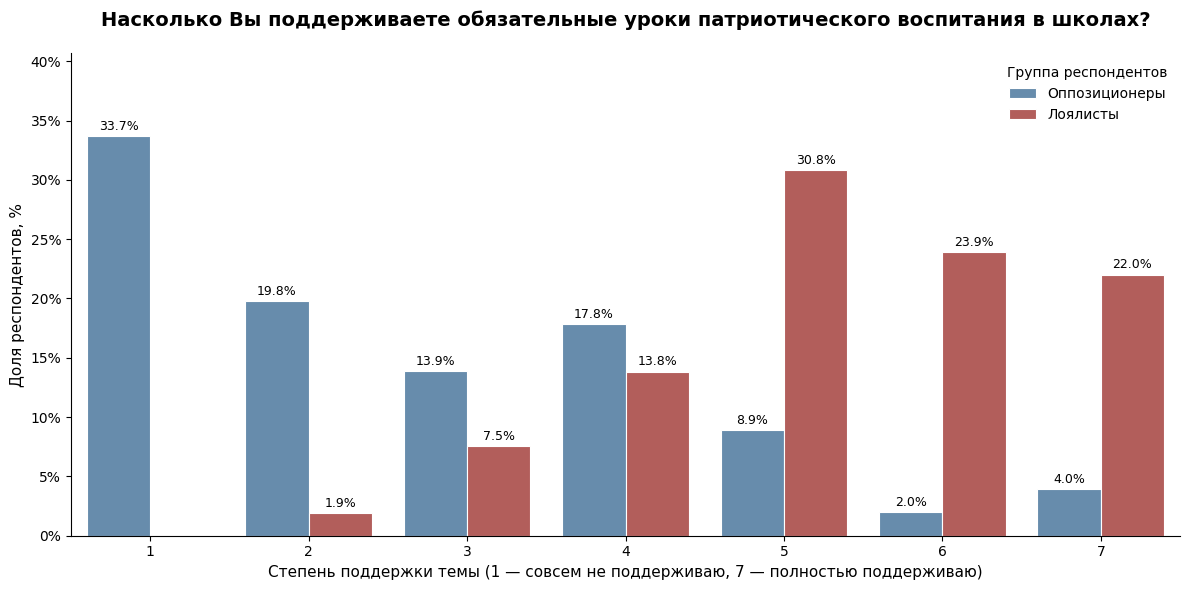

In [ ]:
import matplotlib.ticker as mticker


plot_data = (
    df.groupby('support_bin')['topic_patr_class']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)


plot_data['support_bin'] = plot_data['support_bin'].map({0: 'Оппозиционеры', 1: 'Лоялисты'})


plt.figure(figsize=(12, 6))

colors = {'Оппозиционеры': '#5B8DB8', 'Лоялисты': '#C0504D'}

ax = sns.barplot(
    data=plot_data,
    x='topic_patr_class',
    y='percentage',
    hue='support_bin',
    palette=colors,
    edgecolor='white',
    linewidth=0.8
)


for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    fontsize=9, color='black',
                    xytext=(0, 7),
                    textcoords='offset points')


ax.set_title('Насколько Вы поддерживаете обязательные уроки патриотического воспитания в школах?',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Степень поддержки темы (1 — совсем не поддерживаю, 7 — полностью поддерживаю)', fontsize=11)
ax.set_ylabel('Доля респондентов, %', fontsize=11)


ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

ax.legend(title='Группа респондентов', frameon=False, fontsize=10)


sns.despine()


ax.set_ylim(0, plot_data['percentage'].max() + 7)

plt.tight_layout()
plt.savefig('topic_combined_support.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
polarazing_topics = ttest_results[((ttest_results['crit_mean'] >= 5) & (ttest_results['sup_mean'] <=3)) |
                                                  ((ttest_results['crit_mean'] <=3) & (ttest_results['sup_mean'] >= 5))]['topic'].to_list()

polarazing_topics

['topic_patr_class', 'topic_citiz_depriv', 'topic_army', 'topic_bord_screen']

In [ ]:
ttest_results[ttest_results['topic'].isin(['topic_patr_class', 'topic_citiz_depriv', 'topic_army', 'topic_bord_screen'])]

,topic,sup_mean,crit_mean,mean_diff,t_stat,p_value
3,topic_patr_class,5.333333,2.702970,2.630363,-13.445448,0.0
8,topic_citiz_depriv,5.289308,2.841584,2.447724,-10.306109,0.0
5,topic_army,5.270440,2.980198,2.290242,-11.275764,0.0
4,topic_bord_screen,5.220126,2.940594,2.279532,-10.167414,0.0


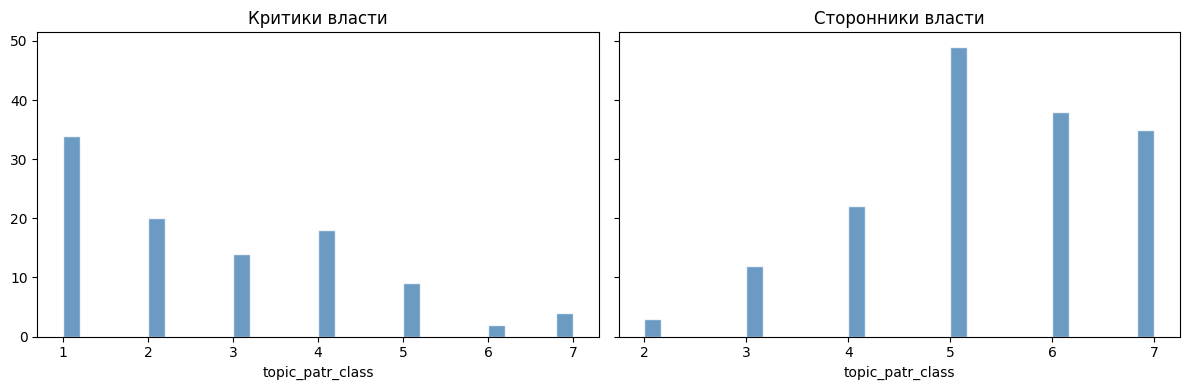

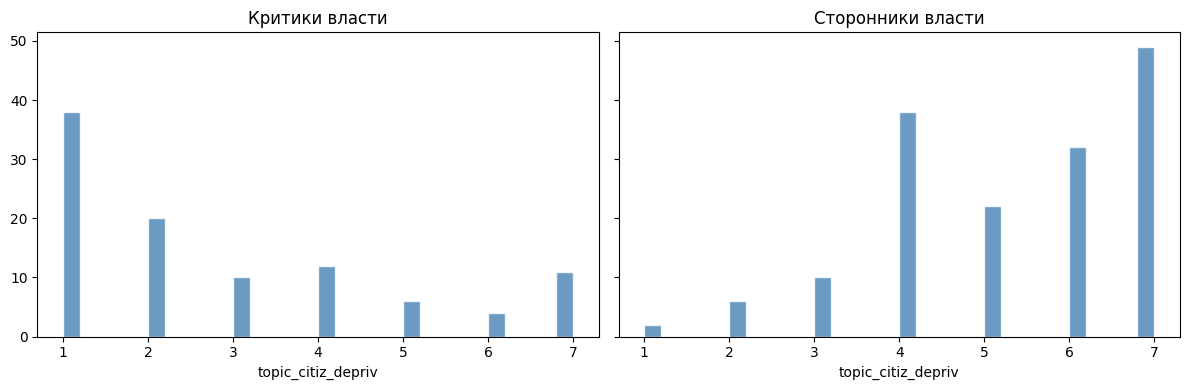

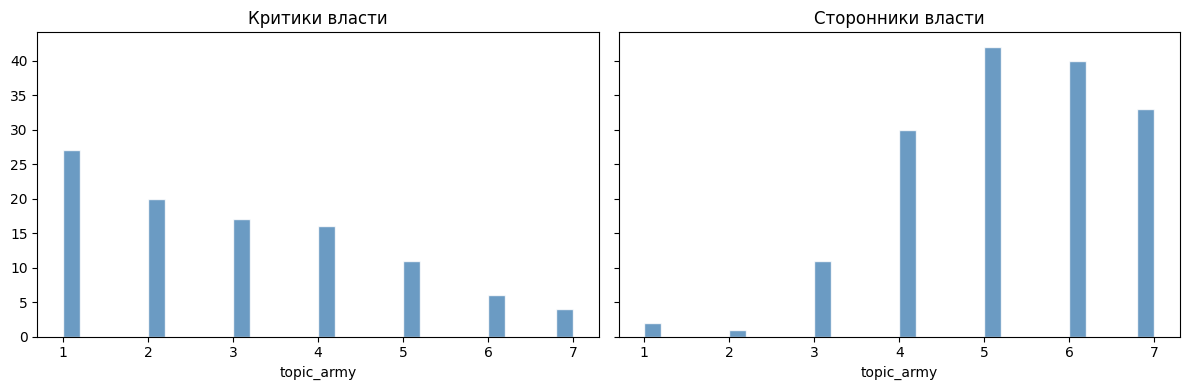

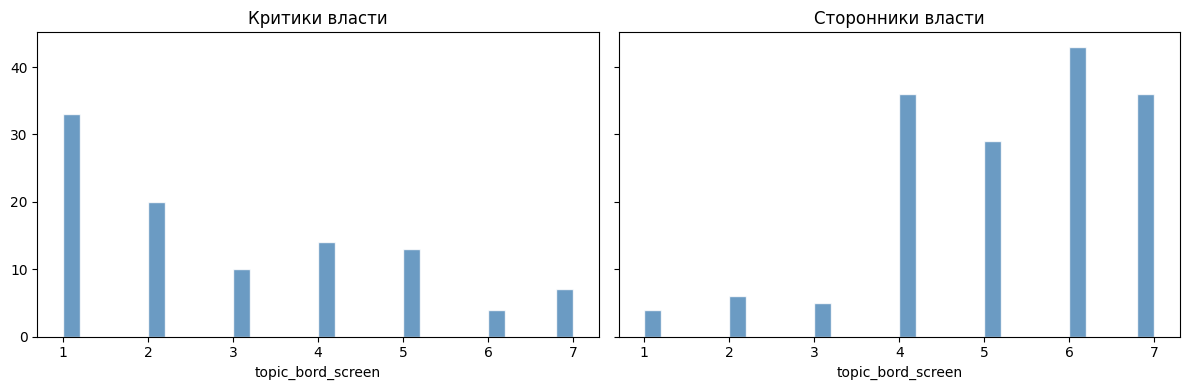

In [ ]:
# выведем графики для этих тем
for i in polarazing_topics:
  fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

  for ax, (group, data) in zip(axes, df.groupby('support_bin')[i]):
      ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
      if group == 0:
        ax.set_title(f'Критики власти')
      else:
        ax.set_title(f'Сторонники власти')

      ax.set_xlabel(i)

  plt.tight_layout()
  plt.show()

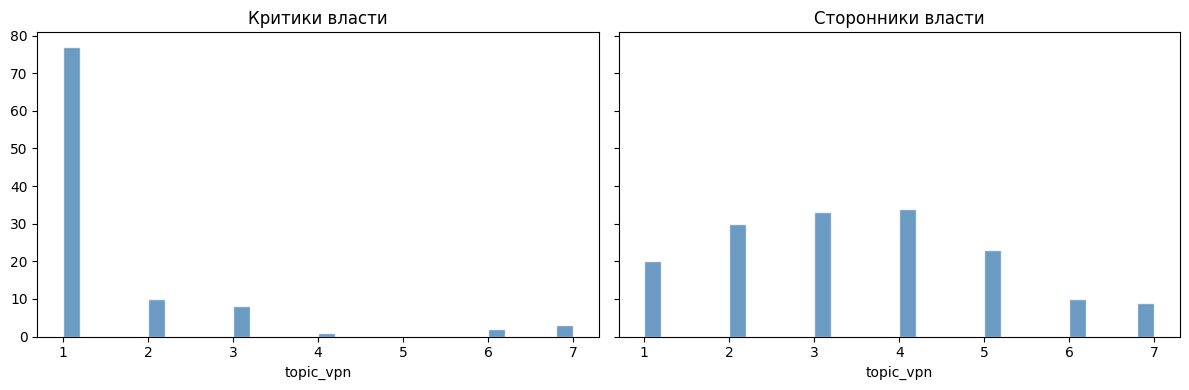

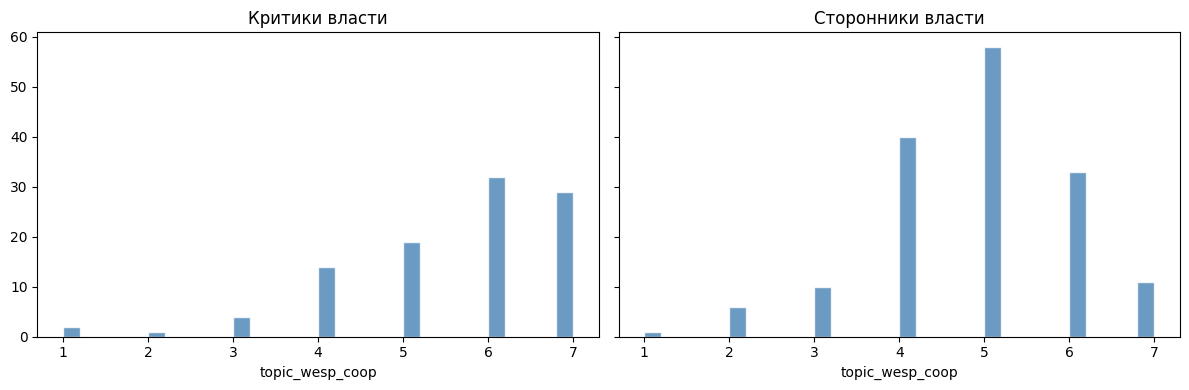

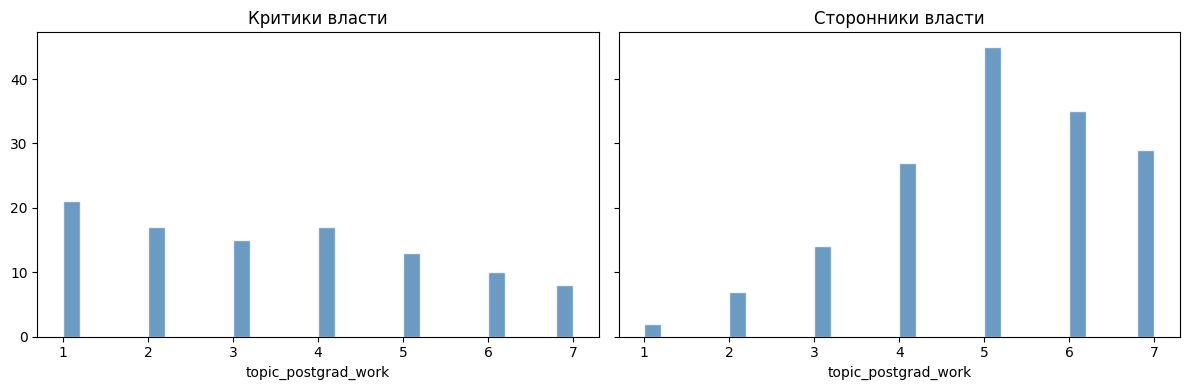

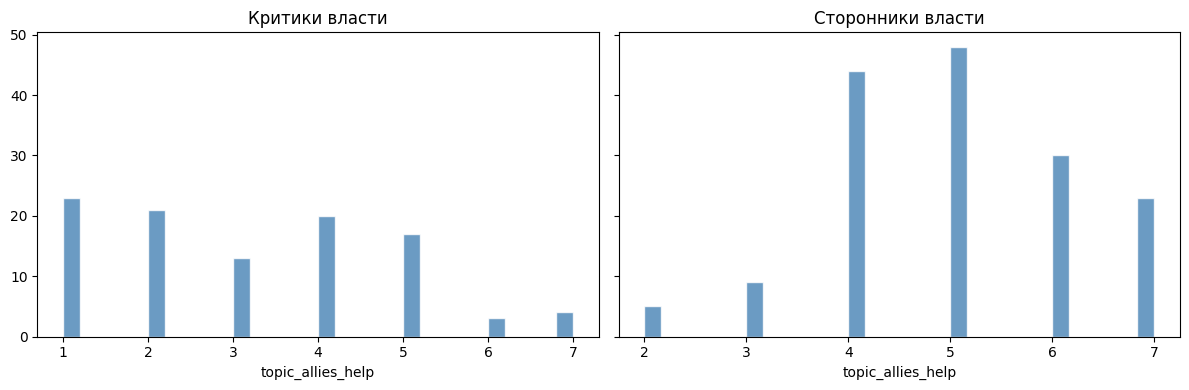

In [ ]:
# теперь выведем для не поляризующих тем, в качестве примера для первых 4
non_polarazing_topics = [x for x in topic_cols if x not in polarazing_topics]

# выведем графики для этих тем
for i in non_polarazing_topics[:4]:
  fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

  for ax, (group, data) in zip(axes, df.groupby('support_bin')[i]):
      ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
      if group == 0:
        ax.set_title(f'Критики власти')
      else:
        ax.set_title(f'Сторонники власти')

      ax.set_xlabel(i)

  plt.tight_layout()
  plt.show()

главная особенность распределений мнений по не поляризующим темам -- равномерность в одном из политических лагерей

In [ ]:
# теперь найдем самую важную из тем, не вызывающую разницу в средних оценках между сторонниками и критиками власти
non_significant_topics = ttest_results[ttest_results['p_value'] > 0.01]['topic'].to_list()
non_significant_topics

['topic_progr_tax',
 'topic_circus_animal',
 'topic_euthan',
 'topic_sec_foreign_lang']

## РЕГРЕССИи

### сначала построим линейные регрессии, где зависимая переменная -- позиция по теме, а объясняющие -- support_bin + контроли. Для оценок коэффициентов при темах выведем доверительные интервалы

In [ ]:
controls = ["gender", "age", "educ", "money", "city"]

reg_results = []
for topic in topic_cols:
    formula = (
        f"{topic} ~ support_bin + "
        f"C(gender) + C(age) + C(educ) + C(money) + C(city)"
    )

    model = smf.ols(
        formula=formula,
        data=df
    ).fit(cov_type="HC3")

    coef = model.params["support_bin"]
    se = model.bse["support_bin"]
    p_value = model.pvalues["support_bin"]

    ci_low, ci_high = model.conf_int().loc["support_bin"]

    reg_results.append({
        "topic": topic,
        "coef": coef,
        "se": se,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "p_value": p_value
    })

reg_results = pd.DataFrame(reg_results).sort_values("coef", ascending=False).reset_index(drop=True).round(3)

reg_results

,topic,coef,se,ci_low,ci_high,p_value
0,topic_patr_class,2.247,0.196,1.862,2.631,0.000
1,topic_messenger,2.222,0.189,1.853,2.592,0.000
2,topic_citiz_depriv,2.055,0.244,1.576,2.534,0.000
3,topic_milit_force,1.888,0.206,1.486,2.291,0.000
4,topic_army,1.809,0.205,1.407,2.211,0.000
5,topic_bord_screen,1.777,0.243,1.302,2.253,0.000
6,topic_allies_help,1.739,0.196,1.354,2.123,0.000
7,topic_vpn,1.577,0.185,1.214,1.940,0.000
8,topic_milit_indust,1.527,0.154,1.226,1.829,0.000
9,topic_relig_educ,1.453,0.197,1.067,1.839,0.000


получили, что поляризующая тема с самой большой разницей в средних -- проведение патриотических уроков. в среднем при прочих равных подержка проведения патриотических уроков в школе сторонниками власти выше на 2.471, чем у критиков власти

на втором месте -- тема использования единого национального мессенджера, на третьем -- лишение гражданства за непатриотические высказывания

# **II. Второй путь: учесть не уверенных в себе респондентов и использовать переменную support в исходном виде**

### снова построим линейные регрессии по аналогии с тем, что делали выше

In [ ]:
df = pd.read_excel('/content/data_raw.xlsx')
columns = df.iloc[0, :].to_list()
# проверки на внимательность
df = df[(df['Q6d'] == 2) & (df['Q31a'] == 3) & (df['Q53a'] == 5)]

# норм названия колонок
df.columns = columns

# удаляем отрицательные значения
df = df[~(df < 0).any(axis=1)]

df = df.apply(pd.to_numeric, errors="coerce")

In [ ]:
controls = ["gender", "age", "educ", "money", "city"]

reg_results = []
for topic in topic_cols:
    formula = (
        f"{topic} ~ support + "
        f"C(gender) + C(age) + C(educ) + C(money) + C(city)"
    )

    model = smf.ols(
        formula=formula,
        data=df
    ).fit(cov_type="HC3")

    coef = model.params["support"]
    se = model.bse["support"]
    p_value = model.pvalues["support"]

    ci_low, ci_high = model.conf_int().loc["support"]

    reg_results.append({
        "topic": topic,
        "coef": coef,
        "se": se,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "p_value": p_value
    })

reg_results = pd.DataFrame(reg_results).sort_values("coef", ascending=False).reset_index(drop=True).round(3)

reg_results

,topic,coef,se,ci_low,ci_high,p_value
0,topic_patr_class,0.623,0.048,0.528,0.717,0.000
1,topic_messenger,0.621,0.044,0.535,0.707,0.000
2,topic_citiz_depriv,0.559,0.059,0.443,0.675,0.000
3,topic_allies_help,0.527,0.045,0.439,0.615,0.000
4,topic_milit_force,0.522,0.050,0.424,0.620,0.000
5,topic_bord_screen,0.519,0.056,0.408,0.629,0.000
6,topic_army,0.481,0.052,0.379,0.582,0.000
7,topic_vpn,0.469,0.050,0.371,0.567,0.000
8,topic_milit_indust,0.415,0.037,0.342,0.488,0.000
9,topic_relig_educ,0.411,0.049,0.315,0.507,0.000


видим, что топ-7 тем сохранился

# Серия 2. Ищем поляризацию по демографическим группам

## 1.гендер

In [ ]:
results = []

for col in topic_cols:
    group0 = df.loc[df["gender"] == 1, col].dropna() #female
    group1 = df.loc[df["gender"] == 2, col].dropna()    #male

    t_stat, p_value = ttest_ind(group0, group1, equal_var = False)

    results.append({
        "topic": col,
        "female_mean": group0.mean(),
        "male_mean": group1.mean(),
        "mean_diff": abs(group1.mean() - group0.mean()),
        "t_stat": t_stat,
        "p_value": round(p_value, 4)
    })

ttest_results = pd.DataFrame(results)
ttest_results = ttest_results.sort_values("mean_diff", ascending = False)

ttest_results

,topic,female_mean,male_mean,mean_diff,t_stat,p_value
5,topic_army,4.765432,3.894366,0.871066,4.261890,0.0000
0,topic_vpn,3.006173,2.309859,0.696314,3.566906,0.0004
4,topic_bord_screen,4.567901,3.894366,0.673535,3.048952,0.0025
3,topic_patr_class,4.530864,3.992958,0.537906,2.553910,0.0112
12,topic_circus_animal,4.790123,4.267606,0.522518,2.552781,0.0112
20,topic_relig_educ,3.191358,2.732394,0.458964,2.327935,0.0206
15,topic_messenger,3.833333,3.450704,0.382629,1.767836,0.0781
19,topic_prohib_adopt,4.222222,3.915493,0.306729,1.463629,0.1443
8,topic_citiz_depriv,4.388889,4.183099,0.205790,0.866834,0.3867
22,topic_sec_foreign_lang,4.746914,4.577465,0.169449,0.959480,0.3381


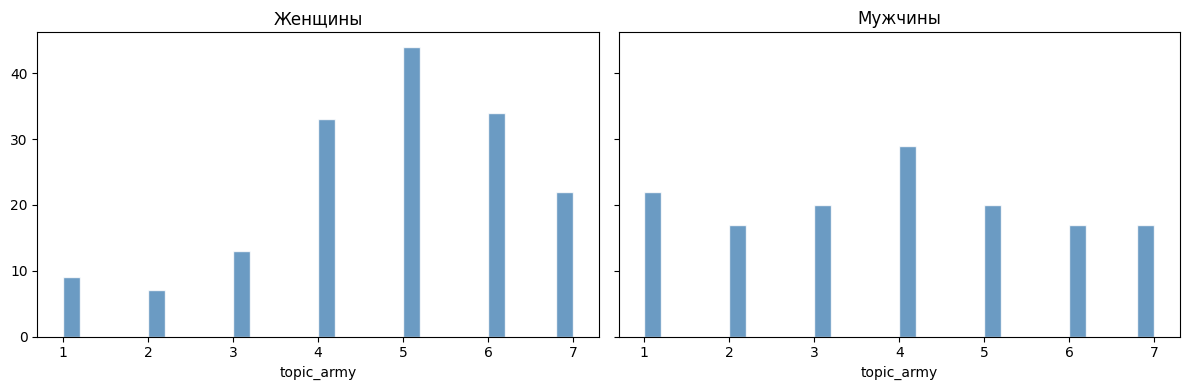

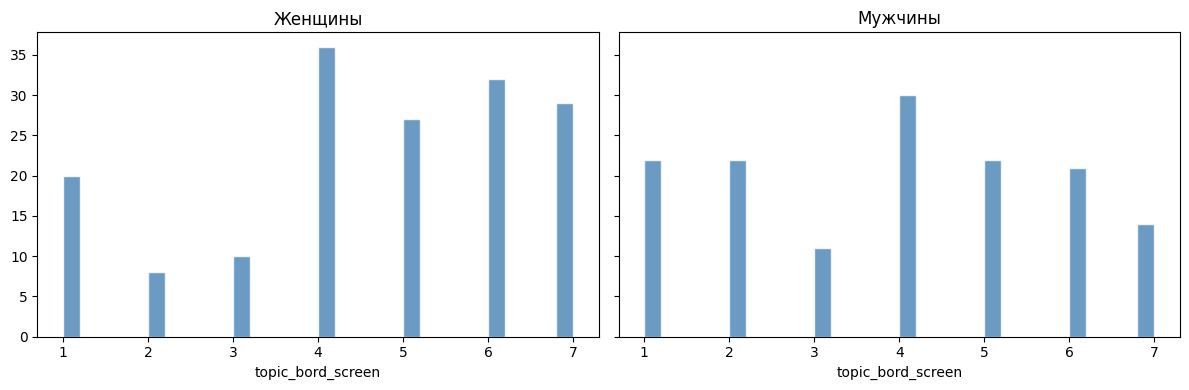

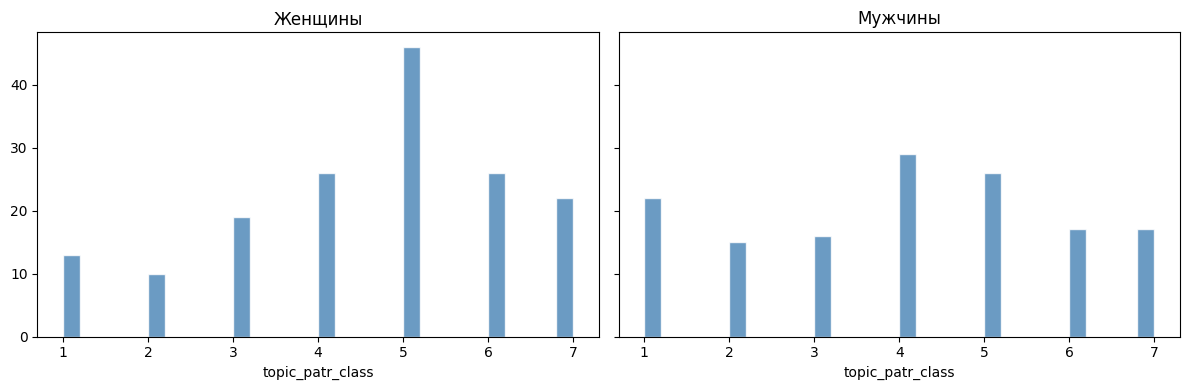

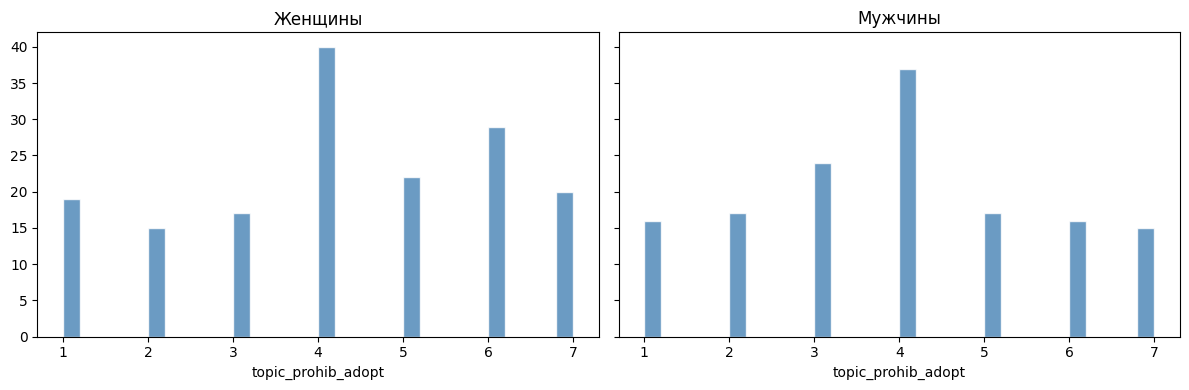

In [ ]:
gender_polarization = ttest_results[((ttest_results['female_mean'] > 4) & (ttest_results['male_mean'] < 4)) |
                                                  ((ttest_results['female_mean'] < 4) & (ttest_results['male_mean'] > 4))]['topic'].to_list()

# выведем графики для этих тем
for i in gender_polarization:
  fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

  for ax, (group, data) in zip(axes, df.groupby('gender')[i]):
      ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
      if group == 1:
        ax.set_title(f'Женщины')
      else:
        ax.set_title(f'Мужчины')

      ax.set_xlabel(i)

  plt.tight_layout()
  plt.show()

вывод: поляризации по полу нет, это хорошо

## 2.возраст (18-35 -> 0, остальные 1)

In [ ]:
df['age'].value_counts()

,count
age,
2,110
3,80
4,49
1,36
5,24
6,5


In [ ]:
df["age_bin"] = np.where(df["age"].isin([1, 2]), 0, 1)
# 1 - 18-24
# 2 - 25-34
df["age_bin"].value_counts()

,count
age_bin,
1,140
0,120


In [ ]:
results = []

for col in topic_cols:
    group0 = df.loc[df["age_bin"] == 0, col]
    group1 = df.loc[df["age_bin"] == 1, col]

    t_stat, p_value = ttest_ind(group0, group1, equal_var = False)

    results.append({
        "topic": col,
        "young_mean": group0.mean(),
        "old_mean": group1.mean(),

        "mean_diff": abs(group1.mean() - group0.mean()),
        "t_stat": t_stat,
        "p_value": round(p_value, 4)
    })

ttest_results = pd.DataFrame(results)
ttest_results = ttest_results.sort_values("mean_diff", ascending = False)

ttest_results

,topic,young_mean,old_mean,mean_diff,t_stat,p_value
12,topic_circus_animal,5.109589,4.025316,1.084273,5.457359,0.0000
11,topic_death_pen,3.856164,4.810127,0.953962,-4.445175,0.0000
16,topic_milit_force,4.178082,5.050633,0.872551,-4.472782,0.0000
3,topic_patr_class,3.835616,4.689873,0.854257,-4.149376,0.0000
17,topic_abort,2.835616,3.645570,0.809953,-3.876358,0.0001
5,topic_army,3.952055,4.734177,0.782122,-3.859107,0.0001
15,topic_messenger,3.260274,4.018987,0.758713,-3.543841,0.0005
2,topic_postgrad_work,3.931507,4.689873,0.758367,-3.817313,0.0002
8,topic_citiz_depriv,3.904110,4.651899,0.747789,-3.216213,0.0014
19,topic_prohib_adopt,3.705479,4.424051,0.718571,-3.495823,0.0005


In [ ]:
# тут уже больше значимых различий, поэтому отфильтруем

age_polarazing_topics = ttest_results[((ttest_results['young_mean'] > 4) & (ttest_results['old_mean'] < 4)) |
                                                  ((ttest_results['young_mean'] < 4) & (ttest_results['old_mean'] > 4))]['topic'].to_list()

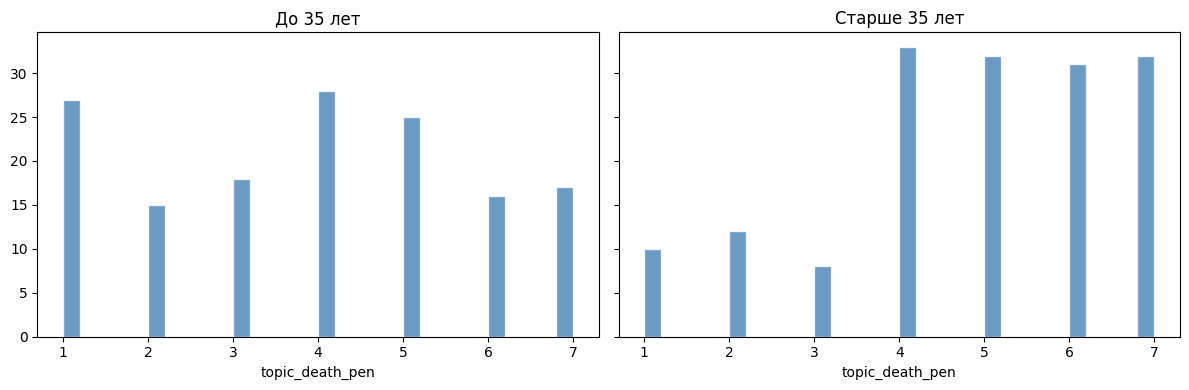

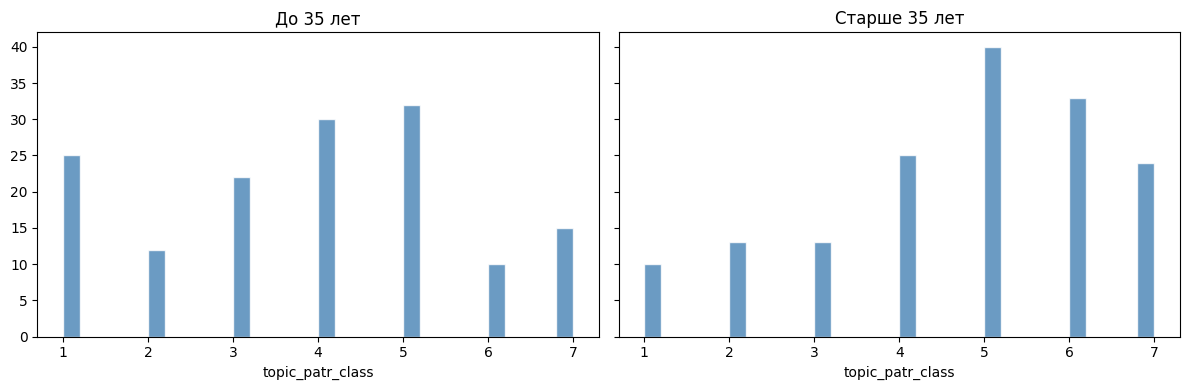

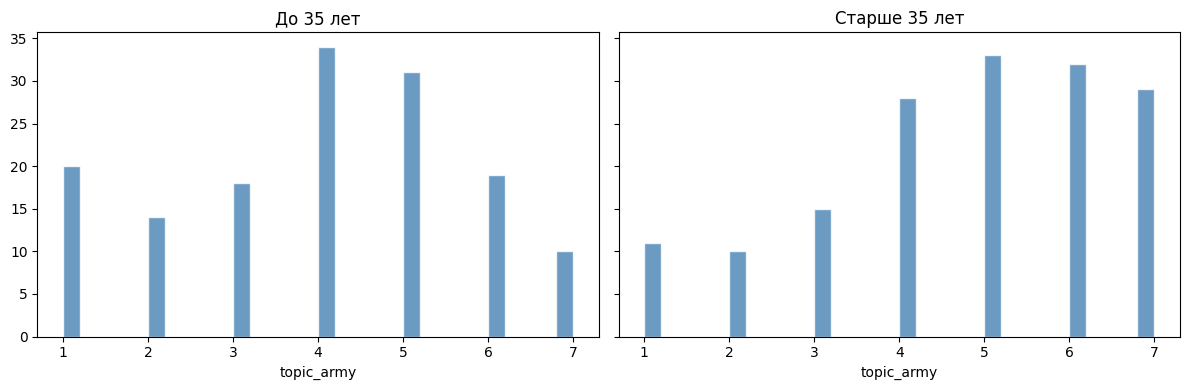

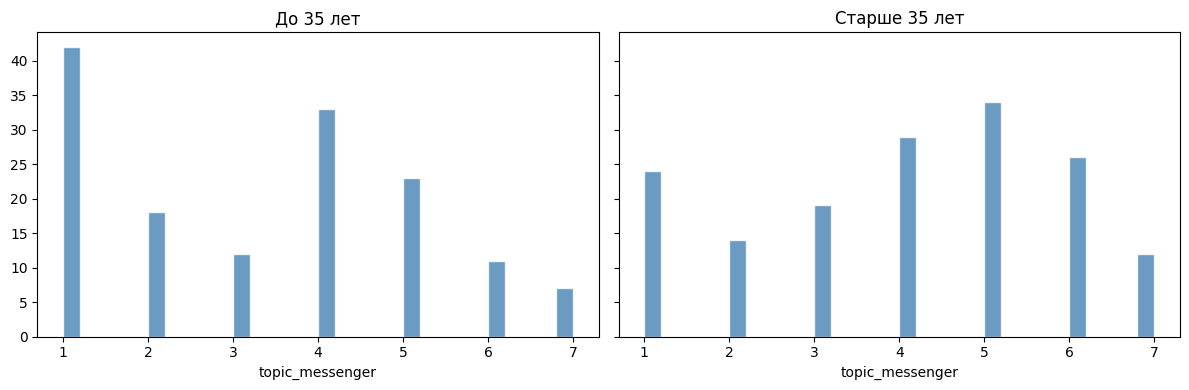

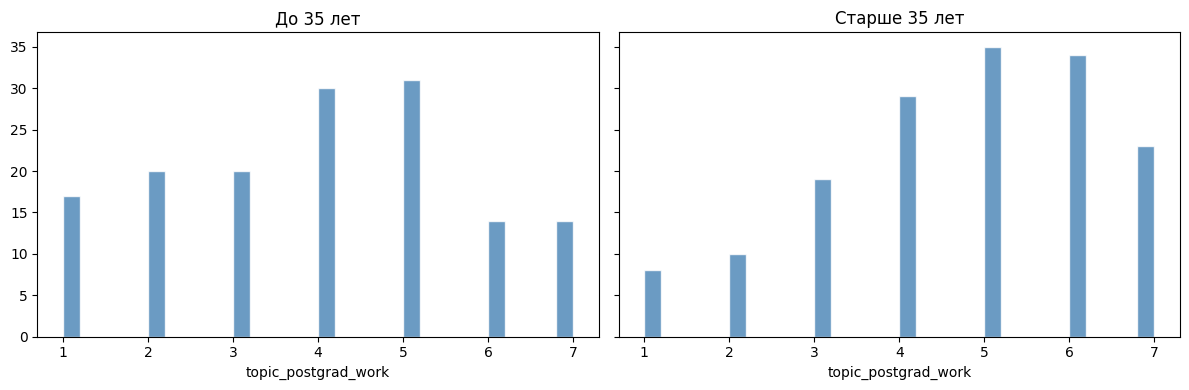

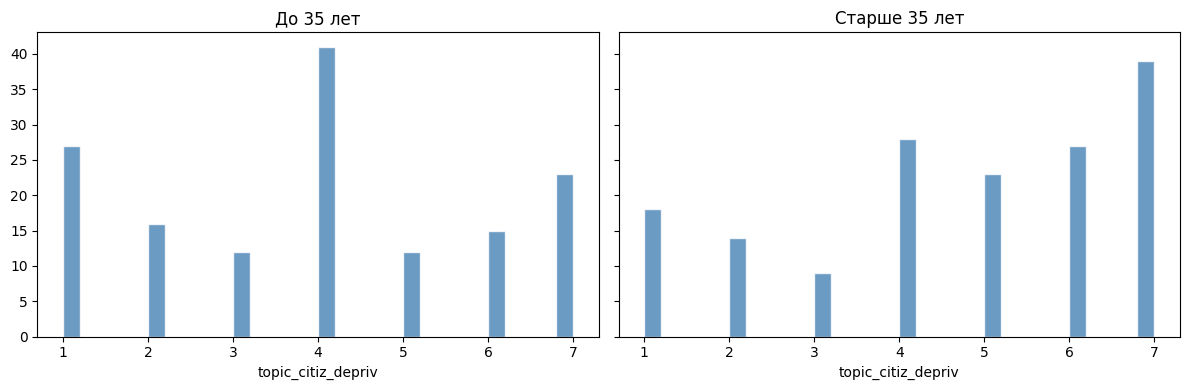

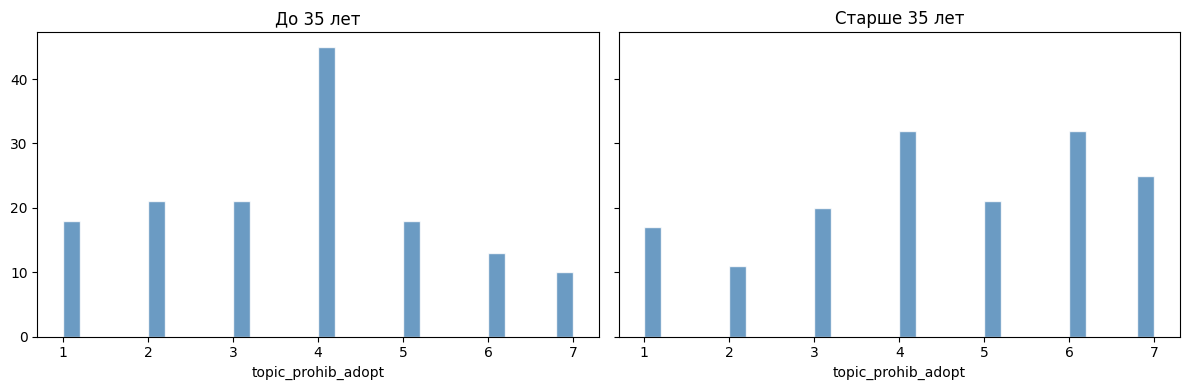

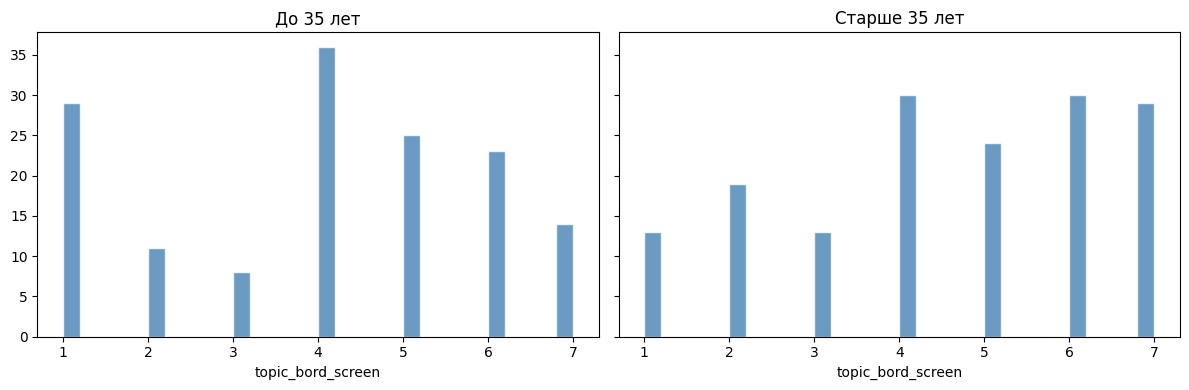

In [ ]:
for i in age_polarazing_topics:
  fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

  for ax, (group, data) in zip(axes, df.groupby('age_bin')[i]):
      ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
      if group == 0:
        ax.set_title(f'До 35 лет')
      else:
        ax.set_title(f'Старше 35')

      ax.set_xlabel(i)

  plt.tight_layout()
  plt.show()

все еще нет такой поляризации, как по политическим взглядам

In [ ]:
df.groupby('support_bin')['age_bin'].value_counts()

support_bin  age_bin
0            0          51
             1          50
1            1          90
             0          69
Name: count, dtype: int64

## 3.образование: 0 - нет высшего, 1 -- есть

In [ ]:
df["educ_bin"] = np.where(df["educ"].isin([1, 2,3]), 0, 1)
# 1,2,3 - нет высшего
# 4,5 - есть высшее\учатся
df["educ_bin"].value_counts()

,count
educ_bin,
1,172
0,132


In [ ]:
results = []

for col in topic_cols:
    group0 = df.loc[df["educ_bin"] == 0, col].dropna()
    group1 = df.loc[df["educ_bin"] == 1, col].dropna()

    t_stat, p_value = ttest_ind(group0, group1, equal_var = False)

    results.append({
        "topic": col,
        "undereduc_mean": group0.mean(),
        "educated_mean": group1.mean(),
        "mean_diff": abs(group1.mean() - group0.mean()),
        "t_stat": t_stat,
        "p_value": round(p_value, 4)
    })


ttest_results = pd.DataFrame(results)
ttest_results = ttest_results.sort_values("mean_diff", ascending = False)

ttest_results

,topic,undereduc_mean,educated_mean,mean_diff,t_stat,p_value
17,topic_abort,3.522727,3.052326,0.470402,2.185853,0.0297
20,topic_relig_educ,3.227273,2.784884,0.442389,2.171196,0.0308
21,topic_childlessness_tax,2.568182,2.151163,0.417019,2.302444,0.0221
0,topic_vpn,2.901515,2.511628,0.389887,1.892811,0.0595
9,topic_progr_tax,4.643939,5.023256,0.379316,-1.991961,0.0474
13,topic_milit_indust,2.878788,2.534884,0.343904,1.981674,0.0486
10,topic_west_sanct,4.750000,4.447674,0.302326,1.865098,0.0632
12,topic_circus_animal,4.681818,4.441860,0.239958,1.159225,0.2473
5,topic_army,4.477273,4.267442,0.209831,1.009290,0.3137
23,topic_euthan,4.515152,4.715116,0.199965,-1.099189,0.2726


In [ ]:
educ_polarazing_topics = ttest_results[((ttest_results['undereduc_mean'] > 4) & (ttest_results['educated_mean'] < 4)) |
                                                  ((ttest_results['undereduc_mean'] < 4) & (ttest_results['educated_mean'] > 4))]['topic'].to_list()

In [ ]:
educ_polarazing_topics

[]

вообще нет поляризации, отлично

## 4.доход: 0 -- 1,2,3 и 1 -- 4,5

In [ ]:
df["money_bin"] = np.where(df["money"].isin([1,2,3]), 0, 1)
df["money_bin"].value_counts()

,count
money_bin,
0,200
1,104


In [ ]:
results = []

for col in topic_cols:
    group0 = df.loc[df["money_bin"] == 0, col].dropna()
    group1 = df.loc[df["money_bin"] == 1, col].dropna()

    t_stat, p_value = ttest_ind(group0, group1, equal_var = False)

    results.append({
        "topic": col,
        "poor_mean": group0.mean(),
        "rich_mean": group1.mean(),
        "mean_diff": abs(group1.mean() - group0.mean()),
        "t_stat": t_stat,
        "p_value": round(p_value, 4)
    })


ttest_results = pd.DataFrame(results)
ttest_results = ttest_results.sort_values("mean_diff", ascending = False)

ttest_results

,topic,poor_mean,rich_mean,mean_diff,t_stat,p_value
0,topic_vpn,2.465,3.096154,0.631154,-2.840763,0.0050
4,topic_bord_screen,4.095,4.557692,0.462692,-1.934073,0.0545
3,topic_patr_class,4.125,4.576923,0.451923,-2.067456,0.0399
16,topic_milit_force,4.480,4.923077,0.443077,-2.096808,0.0372
6,topic_allies_help,4.125,4.528846,0.403846,-2.148128,0.0327
13,topic_milit_indust,2.560,2.923077,0.363077,-1.969197,0.0504
18,topic_nationalization,4.225,4.576923,0.351923,-1.831498,0.0686
15,topic_messenger,3.540,3.875000,0.335000,-1.442074,0.1508
2,topic_postgrad_work,4.225,4.519231,0.294231,-1.377232,0.1699
9,topic_progr_tax,4.760,5.048077,0.288077,-1.572952,0.1170


In [ ]:
money_polarazing_topics = ttest_results[((ttest_results['poor_mean'] > 4) & (ttest_results['rich_mean'] < 4)) |
                                                  ((ttest_results['poor_mean'] < 4) & (ttest_results['rich_mean'] > 4))]['topic'].to_list()

money_polarazing_topics

[]

## 5. населенный пункт

0 -- 3,4,5 -- маленький город

1 -- 1,2 -- больше миллиона

In [ ]:
df["city_bin"] = np.where(df["city"].isin([3,4,5]), 0, 1)
df["city_bin"].value_counts()

,count
city_bin,
0,180
1,124


In [ ]:
results = []

for col in topic_cols:
    group0 = df.loc[df["city_bin"] == 0, col].dropna()
    group1 = df.loc[df["city_bin"] == 1, col].dropna()

    t_stat, p_value = ttest_ind(group0, group1, equal_var = False)

    results.append({
        "topic": col,
        "small_city_mean": group0.mean(),
        "big_city_mean": group1.mean(),
        "mean_diff": abs(group1.mean() - group0.mean()),
        "t_stat": t_stat,
        "p_value": round(p_value, 4)
    })


ttest_results = pd.DataFrame(results)
ttest_results = ttest_results.sort_values("mean_diff", ascending = False)

ttest_results

,topic,small_city_mean,big_city_mean,mean_diff,t_stat,p_value
17,topic_abort,3.544444,2.838710,0.705735,3.313626,0.0010
11,topic_death_pen,4.638889,3.935484,0.703405,3.153030,0.0018
3,topic_patr_class,4.561111,3.870968,0.690143,3.256884,0.0013
8,topic_citiz_depriv,4.572222,3.887097,0.685125,2.852419,0.0047
5,topic_army,4.594444,4.016129,0.578315,2.772726,0.0060
4,topic_bord_screen,4.483333,3.919355,0.563978,2.454015,0.0148
16,topic_milit_force,4.844444,4.322581,0.521864,2.551104,0.0113
15,topic_messenger,3.855556,3.362903,0.492652,2.211779,0.0279
19,topic_prohib_adopt,4.261111,3.814516,0.446595,2.113681,0.0355
20,topic_relig_educ,3.133333,2.750000,0.383333,1.919316,0.0560


In [ ]:
city_polarazing_topics = ttest_results[((ttest_results['small_city_mean'] > 4) & (ttest_results['big_city_mean'] < 4)) |
                                                  ((ttest_results['small_city_mean'] < 4) & (ttest_results['big_city_mean'] > 4))]['topic'].to_list()

city_polarazing_topics

['topic_death_pen',
 'topic_patr_class',
 'topic_citiz_depriv',
 'topic_bord_screen',
 'topic_prohib_adopt']

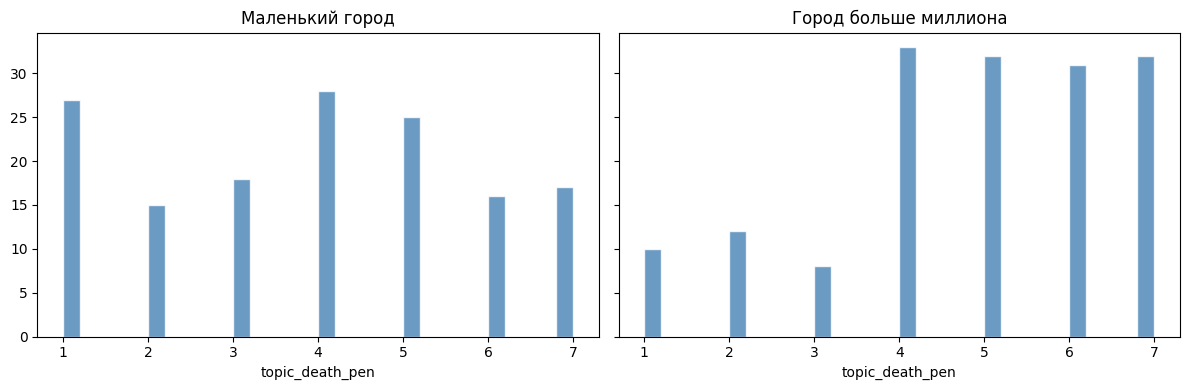

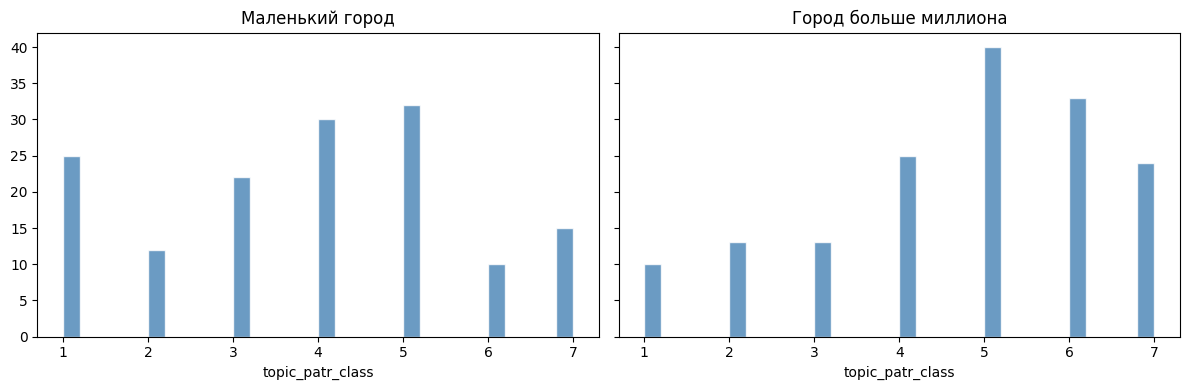

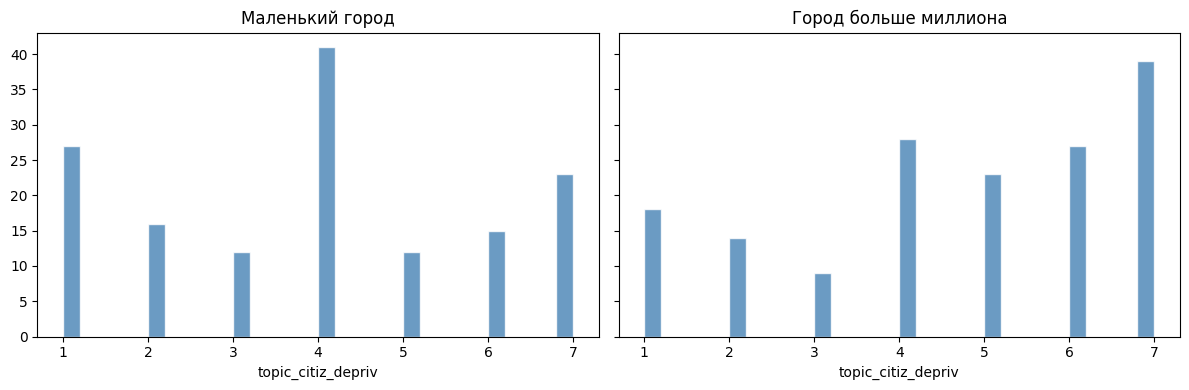

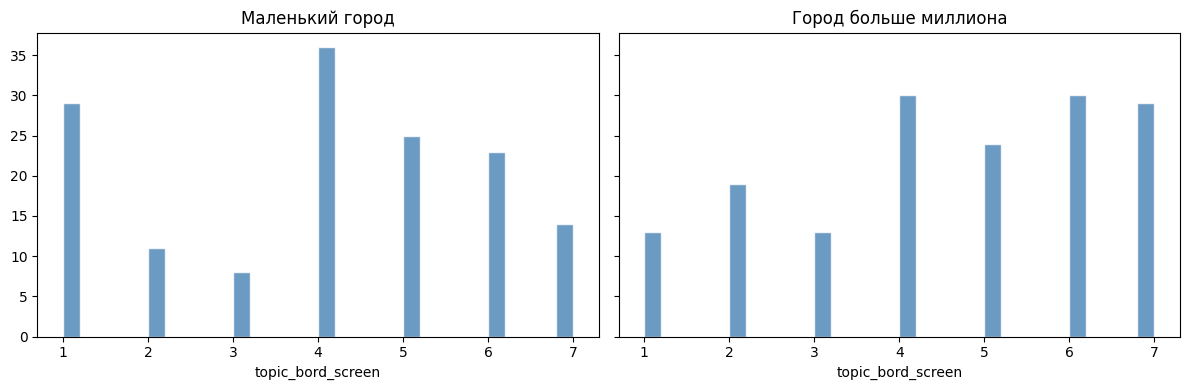

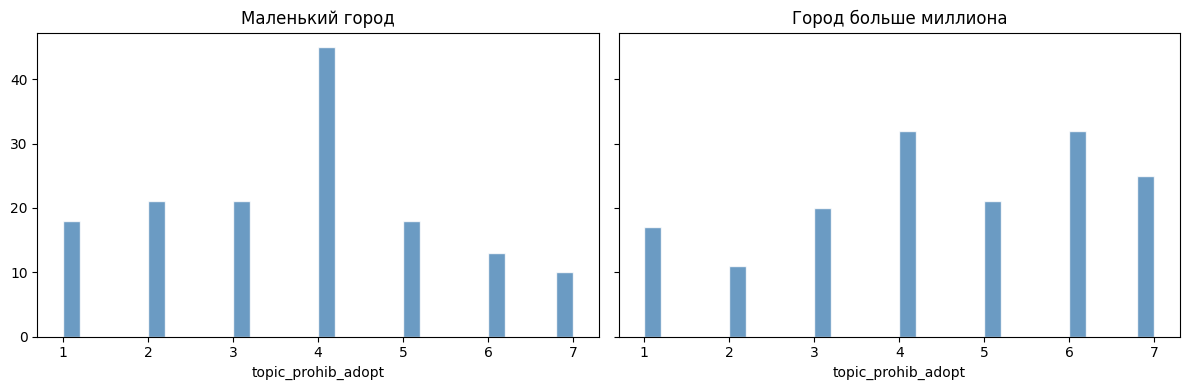

In [ ]:
for i in city_polarazing_topics:
  fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

  for ax, (group, data) in zip(axes, df.groupby('age_bin')[i]):
      ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
      if group == 0:
        ax.set_title(f'Маленький город')
      else:
        ax.set_title(f'Город больше миллиона')

      ax.set_xlabel(i)

  plt.tight_layout()
  plt.show()

# Распределения позиций по темам без деления

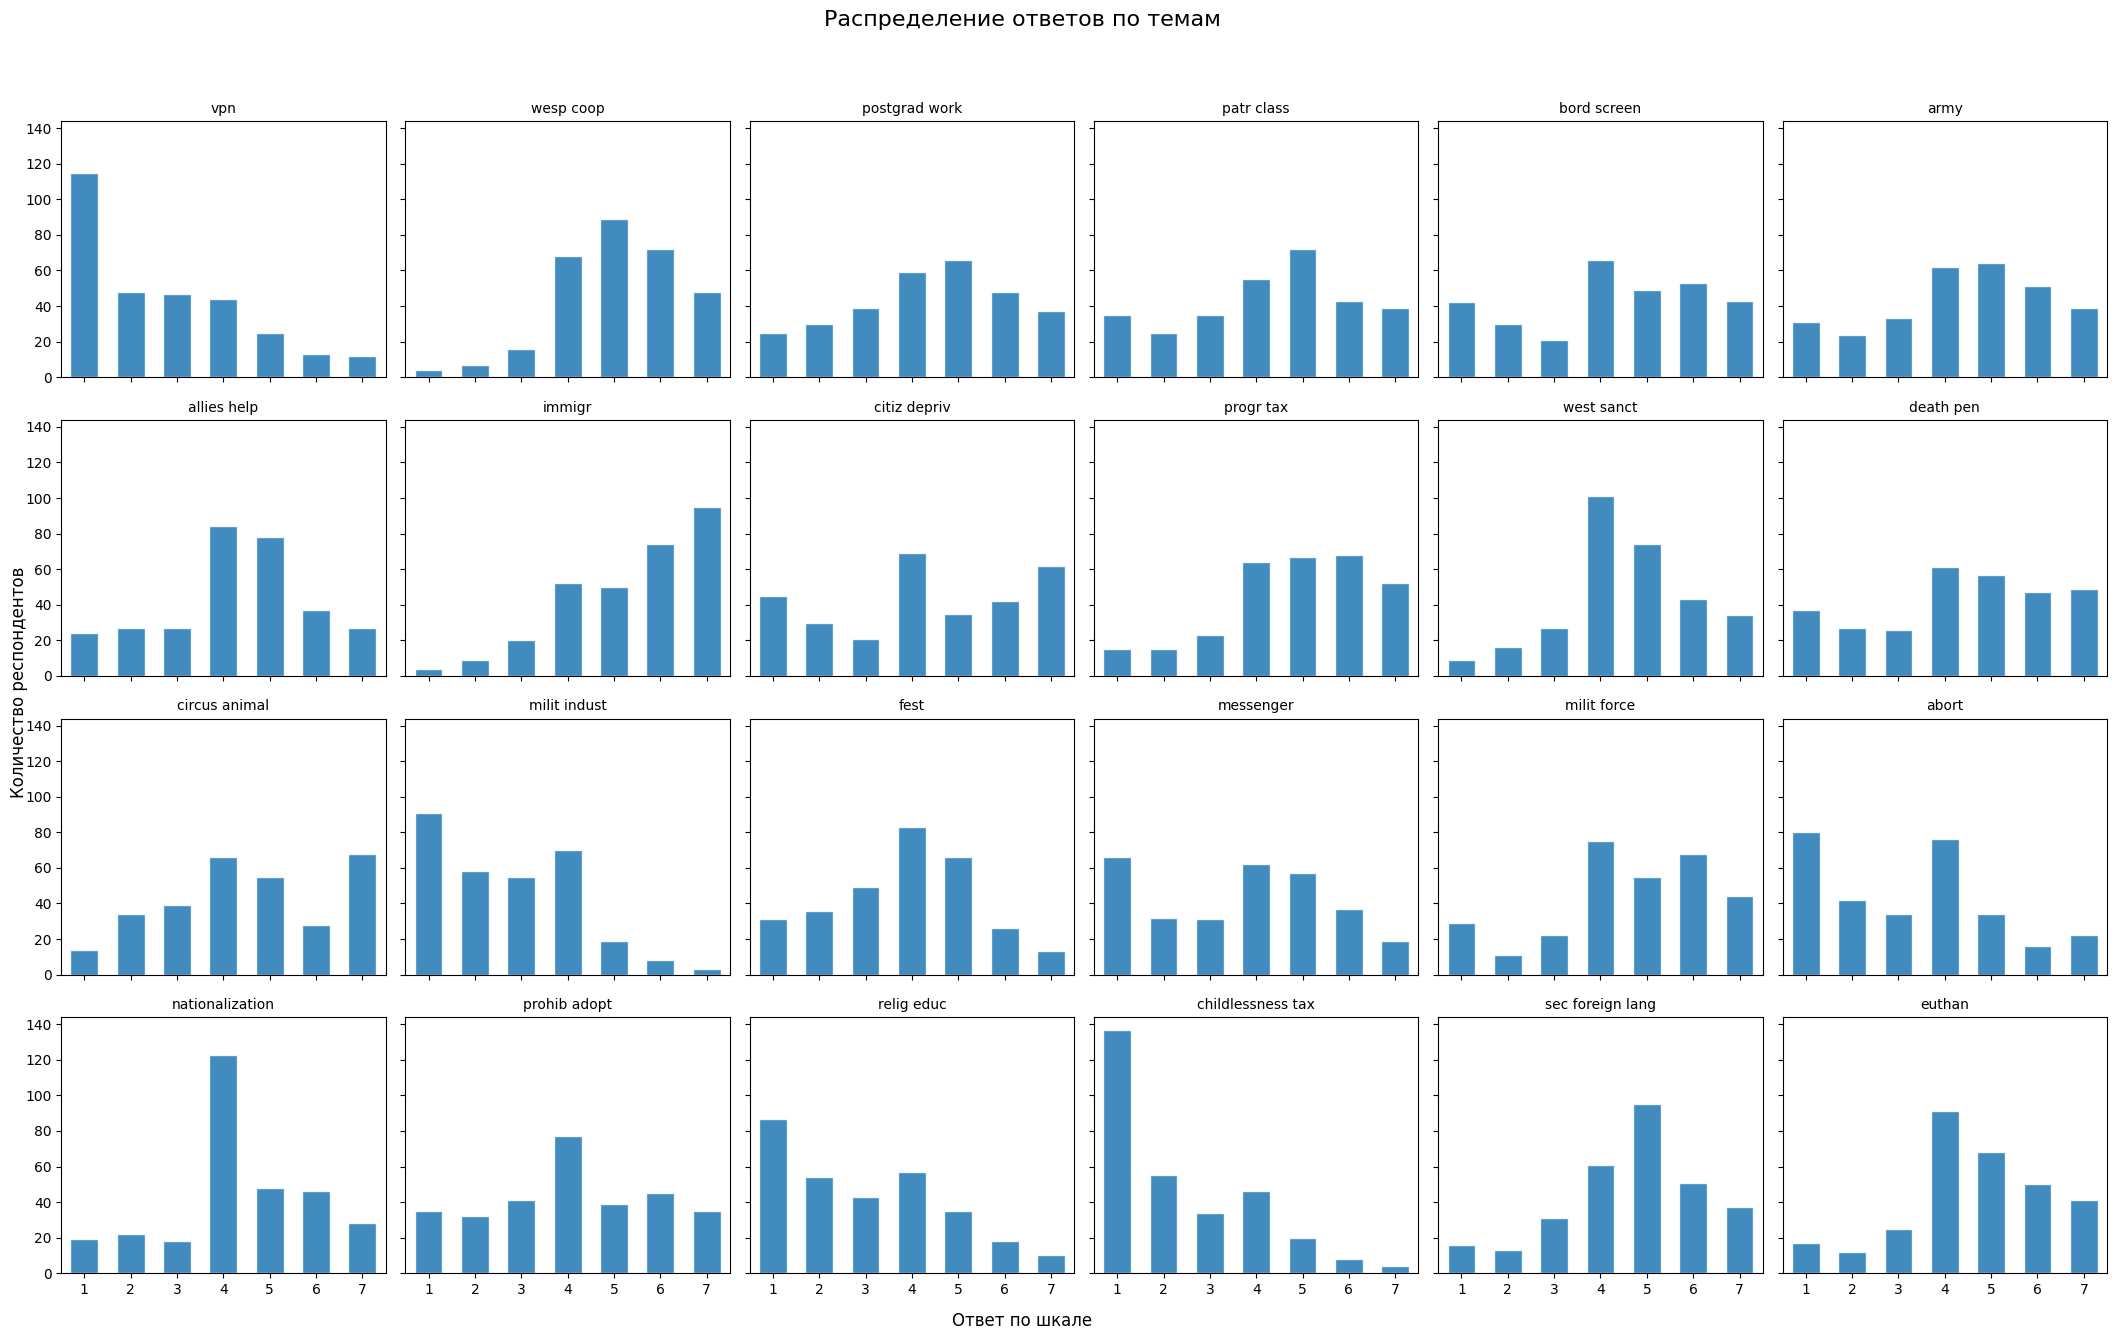

In [ ]:
fig, axes = plt.subplots(4, 6, figsize=(22, 14), sharex=True, sharey=True)

axes = axes.flatten()

for ax, topic in zip(axes, topic_cols):
    data = df[topic].dropna()

    ax.hist(
        data,
        bins=np.arange(0.5, 8.5, 1),
        edgecolor="white",
        alpha=0.85,
        rwidth=0.6
    )

    title = topic.replace("topic_", "").replace("_", " ")
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(1, 8))
    ax.set_xlim(0.5, 7.5)
fig.suptitle("Распределение ответов по темам", fontsize=16)

fig.text(0.5, 0.04, "Ответ по шкале", ha="center", fontsize=12)
fig.text(0.04, 0.5, "Количество респондентов", va="center", rotation="vertical", fontsize=12)

plt.tight_layout(rect=[0.04, 0.05, 1, 0.95])
plt.show()